# Testing Effects of d_bp_max
d_bp_max is a parameter that controls the maximum genomic distance of interactions that are considered for the SCC. The original paper by Yang et al (2017) uses 5 Mb, and my default has been 0.5 Mb. Here, I will determine the effect of d_bp_max on computation time and results.

In [28]:
# Imports and setting up fast reload
%load_ext autoreload
%autoreload 2
import time
import sys
sys.path.append('/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Scripts')
from hicdatautils import calc_scc, avg_scc
import pandas as pd
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


ImportError: cannot import name 'matrix_scc_compare' from 'hicdatautils' (/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Scripts/hicdatautils/__init__.py)

In [6]:
# Importing available files
clp = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/GSE152918_CLP.mcool'
cmp = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/GSE152918_CMP.mcool'
lt = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/GSE152918_LT.mcool'
mk = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/GSE152918_MK.mcool'
st = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/GSE152918_ST.mcool'

files = [clp, cmp, lt, mk, st]

In [7]:
# Testing standard computation lt st
results = []
d_bp_max_list = [100_000, 500_000, 1_000_000, 5_000_000, 10_000_000, 100_000_000, 1_000_000_000]

for d_bp_max in d_bp_max_list:
    # Start timer
    start_time = time.perf_counter()

    # Run comparison
    scc = calc_scc(lt, st, bin_size=10_000, h=20, d_bp_max=d_bp_max, chr_exclude={"M"})

    # End timer
    end_time = time.perf_counter()

    # Calculating average
    scc_avg = avg_scc(scc)

    # Appending to results
    results.append({
        "d_bp_max": d_bp_max,
        "time": end_time - start_time,
        "SCCs": scc,
        "Average SCC": scc_avg
    })

/opt/anaconda3/envs/hictkpyenv/lib/python3.12/site-packages/hicrep/hicrep.py:125: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  assert (cool1.chroms()[:] == cool2.chroms()[:]).all()[0],\
/opt/anaconda3/envs/hictkpyenv/lib/python3.12/site-packages/hicrep/hicrep.py:125: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  assert (cool1.chroms()[:] == cool2.chroms()[:]).all()[0],\
/opt/anaconda3/envs/hictkpyenv/lib/python3.12/site-packages/hicrep/hicrep.py:125: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFram

In [18]:
# Convert to dataframe
df = pd.DataFrame(results)

# Save data for future reference
df.to_csv("/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Generated Data/dBPMax/ltst_dbpmax.csv")

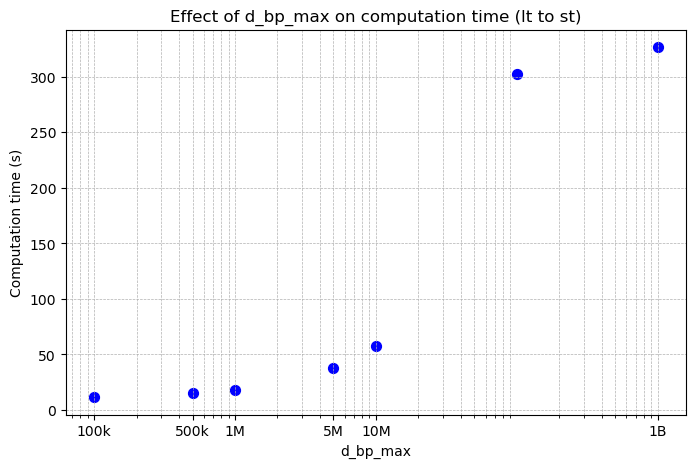

In [9]:
# Imaging d_bp_max in relation to time
plt.figure(figsize=(8,5))
plt.scatter(df["d_bp_max"], df['time'], color='blue', s=50)

    # Logarithmic scale
plt.xscale('log')

    # Labels and titles
plt.xlabel('d_bp_max')
plt.ylabel('Computation time (s)')
plt.title("Effect of d_bp_max on computation time (lt to st)")

    # Formatting x ticks
plt.xticks([1e5, 5e5, 1e6, 5e6, 1e7, 1e9],
           ['100k', '500k', '1M', '5M', '10M', '1B'])

    # Grid
plt.grid(True, which='both', ls='--', lw=0.5)
plt.show()

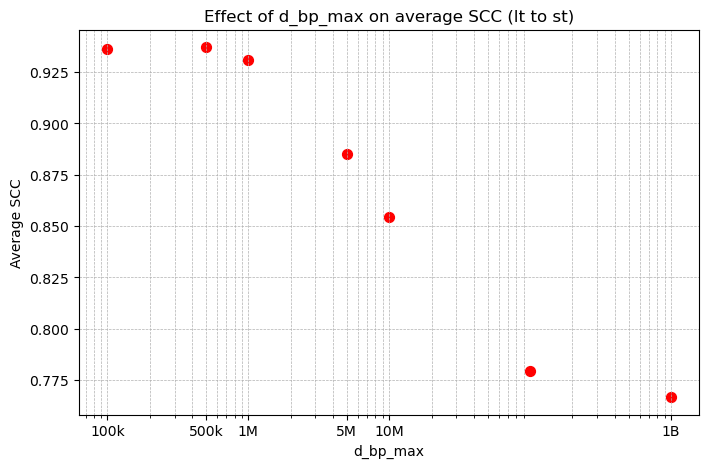

In [10]:
# Imaging d_bp_max in relation to average SCC value
plt.figure(figsize=(8,5))
plt.scatter(df["d_bp_max"], df['Average SCC'], color='red', s=50)

    # Logarithmic scale
plt.xscale('log')

    # Labels and titles
plt.xlabel('d_bp_max')
plt.ylabel('Average SCC')
plt.title("Effect of d_bp_max on average SCC (lt to st)")

    # Formatting x ticks
plt.xticks([1e5, 5e5, 1e6, 5e6, 1e7, 1e9],
           ['100k', '500k', '1M', '5M', '10M', '1B'])

    # Grid
plt.grid(True, which='both', ls='--', lw=0.5)
plt.show()

In [11]:
# Testing standard computation lt mk
results2 = []

for d_bp_max in d_bp_max_list:
    # Start timer
    start_time = time.perf_counter()

    # Run comparison
    scc = calc_scc(lt, mk, bin_size=10_000, h=20, d_bp_max=d_bp_max, chr_exclude={"M"})

    # End timer
    end_time = time.perf_counter()

    # Calculating average
    scc_avg = avg_scc(scc)

    # Appending to results
    results2.append({
        "d_bp_max": d_bp_max,
        "time": end_time - start_time,
        "SCCs": scc,
        "Average SCC": scc_avg
    })

/opt/anaconda3/envs/hictkpyenv/lib/python3.12/site-packages/hicrep/hicrep.py:125: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  assert (cool1.chroms()[:] == cool2.chroms()[:]).all()[0],\
/opt/anaconda3/envs/hictkpyenv/lib/python3.12/site-packages/hicrep/hicrep.py:125: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  assert (cool1.chroms()[:] == cool2.chroms()[:]).all()[0],\
/opt/anaconda3/envs/hictkpyenv/lib/python3.12/site-packages/hicrep/hicrep.py:125: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFram

In [19]:
# Convert to dataframe
df2 = pd.DataFrame(results2)

# Save data for future reference
df2.to_csv("/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Generated Data/dBPMax/ltmk_dbpmax.csv")

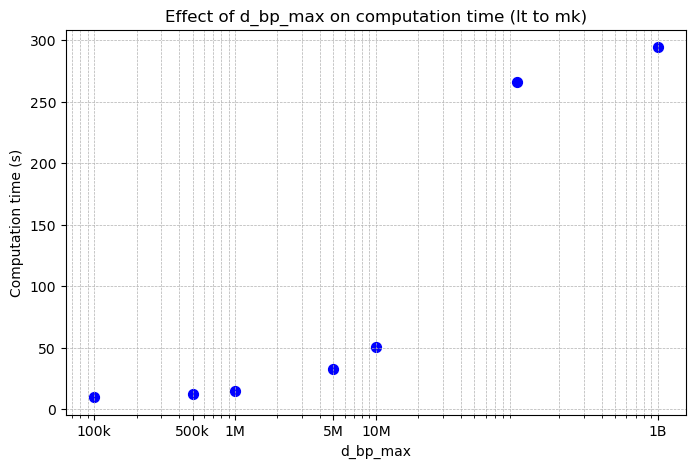

In [15]:
# Imaging d_bp_max in relation to time
plt.figure(figsize=(8,5))
plt.scatter(df2["d_bp_max"], df2['time'], color='blue', s=50)

    # Logarithmic scale
plt.xscale('log')

    # Labels and titles
plt.xlabel('d_bp_max')
plt.ylabel('Computation time (s)')
plt.title("Effect of d_bp_max on computation time (lt to mk)")

    # Formatting x ticks
plt.xticks([1e5, 5e5, 1e6, 5e6, 1e7, 1e9],
           ['100k', '500k', '1M', '5M', '10M', '1B'])

    # Grid
plt.grid(True, which='both', ls='--', lw=0.5)
plt.show()

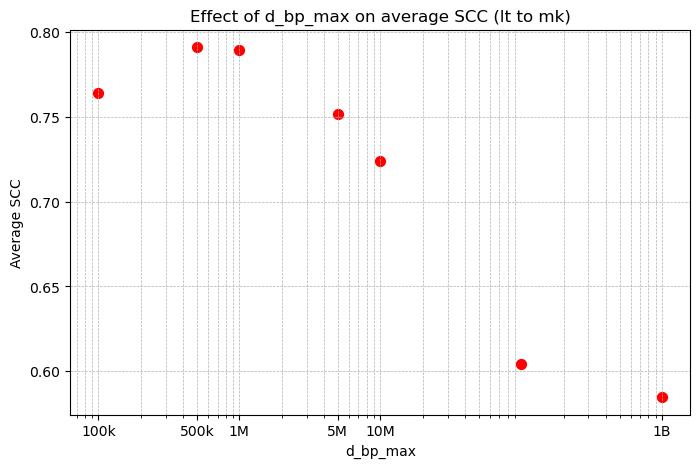

In [16]:
# Imaging d_bp_max in relation to average SCC value
plt.figure(figsize=(8,5))
plt.scatter(df2["d_bp_max"], df2['Average SCC'], color='red', s=50)

    # Logarithmic scale
plt.xscale('log')

    # Labels and titles
plt.xlabel('d_bp_max')
plt.ylabel('Average SCC')
plt.title("Effect of d_bp_max on average SCC (lt to mk)")

    # Formatting x ticks
plt.xticks([1e5, 5e5, 1e6, 5e6, 1e7, 1e9],
           ['100k', '500k', '1M', '5M', '10M', '1B'])

    # Grid
plt.grid(True, which='both', ls='--', lw=0.5)
plt.show()